# Low-Resource Language Sentiment Analysis with Transfer Learning

**Student:** Sayi Khushhal Gadde  

**Student ID:** A00074661

**Dataset (train/eval):** AfriSenti Hausa (`masakhane/afrisenti`, `hau`) — Muhammad et al., EMNLP 2023  

**test dataset:** NollySenti Hausa — Shode et al., ACL 2023

**Huggingface Space:** https://huggingface.co/spaces/sayikhushhal/low-resource-hausa-sentiment

**Huggingface Project link:** https://huggingface.co/sayikhushhal/xlm-r-hausa-sentiment/tree/main

---
# Milestone 1: Data Exploration and Classical Baseline

Load AfriSenti Hausa, explore the data, clean it, then establish a classical TF-IDF + Logistic Regression baseline. This is the reference point the transformer models have to beat in Milestone 2.


## Setup

In [1]:
# Colab doesn't ship with these. Quiet flag just to keep the install log short.
!pip install datasets transformers accelerate torch scikit-learn matplotlib seaborn --quiet

In [2]:
import torch
import torch.nn as nn
import random, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

# Fixing the seeds here - fp16 runs drift between executions otherwise.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


## Dataset

In [3]:
# AfriSenti Hausa dataset
# Source: https://huggingface.co/datasets/masakhane/afrisenti
# Muhammad et al., EMNLP 2023

dataset = load_dataset("masakhane/afrisenti", "hau")

print("RAW DATASET OVERVIEW:\n")
print(f"Type: {type(dataset)}")
print(f"\n{dataset}")
print(f"\nSplits: {list(dataset.keys())}")
print(f"\nFirst example:")
print(dataset["train"][0])

README.md: 0.00B [00:00, ?B/s]

train.tsv: 0.00B [00:00, ?B/s]

dev.tsv: 0.00B [00:00, ?B/s]

test.tsv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/14172 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2677 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5303 [00:00<?, ? examples/s]

RAW DATASET OVERVIEW:

Type: <class 'datasets.dataset_dict.DatasetDict'>

DatasetDict({
    train: Dataset({
        features: ['tweet', 'label'],
        num_rows: 14172
    })
    validation: Dataset({
        features: ['tweet', 'label'],
        num_rows: 2677
    })
    test: Dataset({
        features: ['tweet', 'label'],
        num_rows: 5303
    })
})

Splits: ['train', 'validation', 'test']

First example:
{'tweet': '@user Da kudin da Arewa babu wani abin azo agani da yayi wa alummah allah ya isa yacucemu wlh yarikitamana kasa yarikitamana kasuwanci harkar ilimi harkar lfy hanyoyi babu lantarki dasuransu komai yalalace ga cinhanci da rashawa a fili ko ina a Nigeria jamiyaryar su tabataman mlm 😭🗣', 'label': 'negative'}


In [4]:
# Converting to pandas so I can poke around with .describe and .value_counts.
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print(f"Shape: {train_df.shape[0]} rows x {train_df.shape[1]} columns")
print(f"\nColumn info:")
print(train_df.info())
print("\nLabel counts:", train_df["label"].value_counts())
train_df.head(10)

Shape: 14172 rows x 2 columns

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14172 entries, 0 to 14171
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   14172 non-null  object
 1   label   14172 non-null  object
dtypes: object(2)
memory usage: 221.6+ KB
None

Label counts: label
neutral     4912
positive    4687
negative    4573
Name: count, dtype: int64


,tweet,label
0,@user Da kudin da Arewa babu wani abin azo aga...,negative
1,@user Kaga wani Adu ar Banda💔😭 wai a haka Shi ...,negative
2,@user Sai haquri fa yan madrid daman kunce cha...,negative
3,@user Hmmm yanzu kai kasan girman allah daxaka...,negative
4,@user @user Wai gwamno nin Nigeria suna afa kw...,negative
5,"@user To Ku nemawa talakkawa mafita mana, Maga...",negative
6,@user Wato mutanen ma an koma fasa kwaurin su ...,negative
7,@user Toh ai iyayannaki mah basusan darajan mu...,negative
8,@user 🤣😜🤣😜Shirin ku ya rushe akan Afrika kenan 👌,negative
9,@user Rarara kai dabanne wallah indai a fannin...,negative


## Exploratory Data Analysis (EDA)

In [5]:
# How balanced are the classes? Decides whether weighted loss is worth trying later.
for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    counts = df["label"].value_counts()
    total = len(df)
    print(f"\n{name} ({total} samples):")
    for label in ["positive", "negative", "neutral"]:
        print(f"  {label}: {counts.get(label, 0)} ({counts.get(label, 0)/total*100:.1f}%)")


Train (14172 samples):
  positive: 4687 (33.1%)
  negative: 4573 (32.3%)
  neutral: 4912 (34.7%)

Validation (2677 samples):
  positive: 887 (33.1%)
  negative: 894 (33.4%)
  neutral: 896 (33.5%)

Test (5303 samples):
  positive: 1755 (33.1%)
  negative: 1759 (33.2%)
  neutral: 1789 (33.7%)


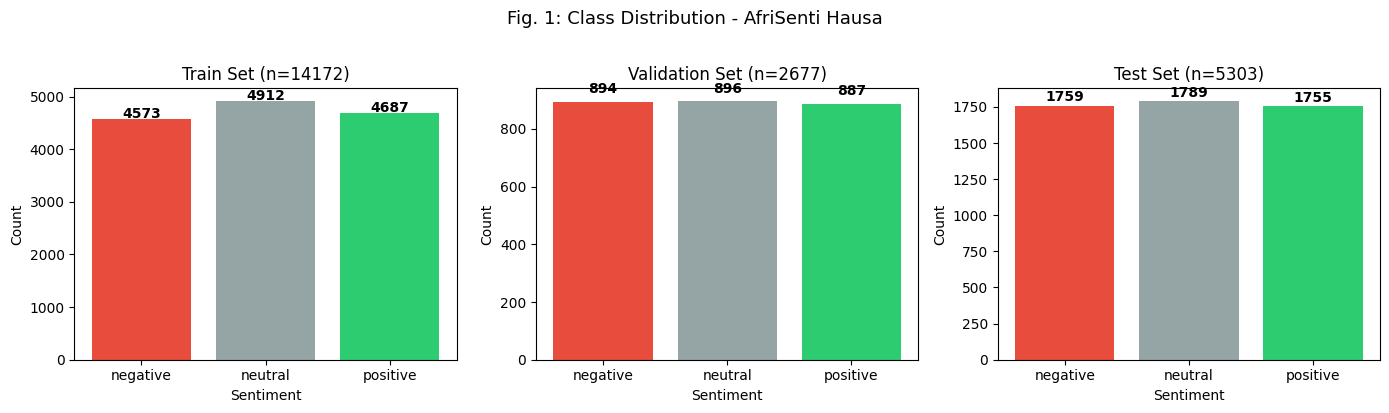

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["#e74c3c", "#95a5a6", "#2ecc71"]
label_order = ["negative", "neutral", "positive"]

for ax, (df, split) in zip(axes, [(train_df, "Train"), (val_df, "Validation"), (test_df, "Test")]):
    counts = df["label"].value_counts().reindex(label_order)
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(f"{split} Set (n={len(df)})")
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 30, str(v), ha="center", fontweight="bold", fontsize=10)

plt.suptitle("Fig. 1: Class Distribution - AfriSenti Hausa", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Length stats - tweets are short but I want an actual number before picking max_length.
train_df["word_count"] = train_df["tweet"].apply(lambda x: len(str(x).split()))
train_df["char_count"] = train_df["tweet"].apply(lambda x: len(str(x)))

print("Text length stats (training set):\n")
print("Words per tweet:")
print(train_df["word_count"].describe().round(2))
print(f"\nChars per tweet:")
print(train_df["char_count"].describe().round(2))

Text length stats (training set):

Words per tweet:
count    14172.00
mean        14.02
std          9.66
min          4.00
25%          7.00
50%         11.00
75%         17.00
max         58.00
Name: word_count, dtype: float64

Chars per tweet:
count    14172.00
mean        78.06
std         55.00
min         17.00
25%         40.00
50%         60.00
75%         97.00
max        337.00
Name: char_count, dtype: float64


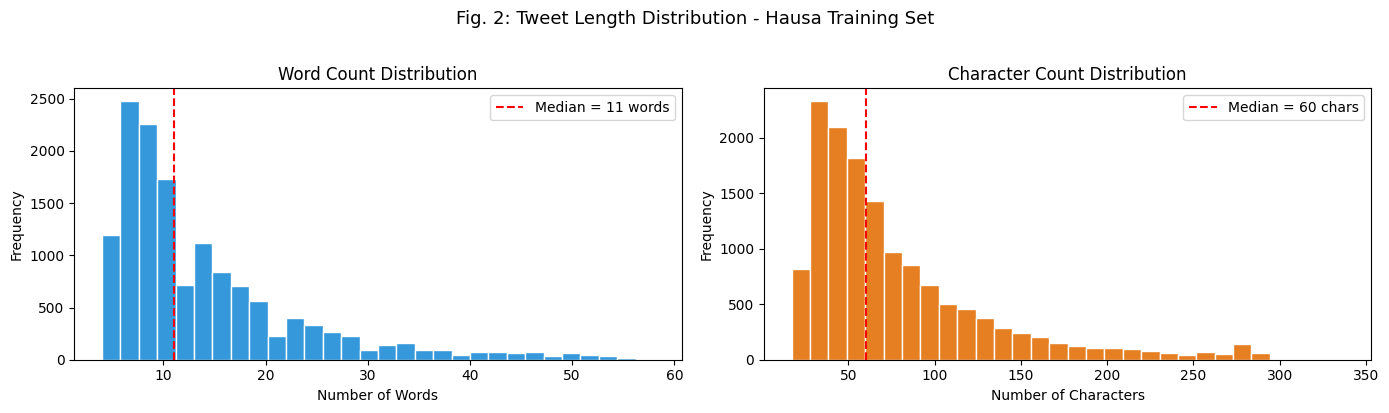

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df["word_count"], bins=30, color="#3498db", edgecolor="white")
axes[0].axvline(train_df["word_count"].median(), color="red", linestyle="--",
               label=f'Median = {train_df["word_count"].median():.0f} words')
axes[0].set_xlabel("Number of Words")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Word Count Distribution")
axes[0].legend()

axes[1].hist(train_df["char_count"], bins=30, color="#e67e22", edgecolor="white")
axes[1].axvline(train_df["char_count"].median(), color="red", linestyle="--",
               label=f'Median = {train_df["char_count"].median():.0f} chars')
axes[1].set_xlabel("Number of Characters")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Character Count Distribution")
axes[1].legend()

plt.suptitle("Fig. 2: Tweet Length Distribution - Hausa Training Set", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("text_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Eyeballing a few examples per class. Sanity check that the labels aren't obvious noise.
print("Sample tweets per class:\n")
for label in ["positive", "negative", "neutral"]:
    print(f"{label.upper()}:")
    samples = train_df[train_df["label"] == label]["tweet"].sample(3, random_state=SEED)
    for i, tweet in enumerate(samples, 1):
        print(f"  [{i}] {tweet[:150]}{'...' if len(tweet) > 150 else ''}")
    print()

Sample tweets per class:

POSITIVE:
  [1] @user Toh! Allah ka tsare mu daga wannan musibar🤲
  [2] @user Allah Yasa Donal Trump Y kawo w Buhari Ziyara suyi Hanu biyu d Shi Amin 🤝
  [3] @user Me precious queen don't get angry 😊turo account number dinki inyi saka ki farinciki😁 @user

NEGATIVE:
  [1] @user @user Wawuya waike kina Washington DC banza kasar dabanakiba harkina alfahari dashi☹️ waike kin Waye ☹️ yau inasu Judge Floyd
  [2] @user Gaskiya ne wato aci gaba da fitowa daga daji ana kashe alumma shine burinka aradu buhari bakason yan arewa, wato #zoo xakison maidamu, Monkey's ...
  [3] @user @user sadau wanan """"""""""""""""bra"""""""""""""""" naki bafi chikin hanu nha bha👌

NEUTRAL:
  [1] @user @user @user @user Sarkin fa, haba rahama 🙏
  [2] 😰😰@user Rabin yaran Sudan ta kudu ba sa zuwa makaranta https://t.co/MMA1s2sN2O
  [3] @user Sabon yabin dai 😹😹



In [10]:
# checking what patterns exist in the tweets before cleaning
has_mention = train_df["tweet"].str.contains(r"@\w+", regex=True)
has_url = train_df["tweet"].str.contains(r"https?://\S+|www\.\S+", regex=True)

emoji_pattern = re.compile(
    "[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF\U00002702-\U000027B0\U0001F900-\U0001F9FF]+",
    flags=re.UNICODE
)
has_emoji = train_df["tweet"].apply(lambda x: bool(emoji_pattern.search(str(x))))
has_hashtag = train_df["tweet"].str.contains(r"#\w+", regex=True)

english_words = r"\b(?:the|is|are|was|this|that|have|has|not|but|for|with|you|your)\b"
has_english = train_df["tweet"].str.contains(english_words, regex=True, case=False)

print(f"@user mentions: {has_mention.sum()} / {len(train_df)} ({has_mention.mean()*100:.1f}%)")
print(f"URLs:           {has_url.sum()} / {len(train_df)} ({has_url.mean()*100:.1f}%)")
print(f"Emojis:         {has_emoji.sum()} / {len(train_df)} ({has_emoji.mean()*100:.1f}%)")
print(f"Hashtags:       {has_hashtag.sum()} / {len(train_df)} ({has_hashtag.mean()*100:.1f}%)")
print(f"English words:  {has_english.sum()} / {len(train_df)} ({has_english.mean()*100:.1f}%)")

@user mentions: 14165 / 14172 (100.0%)
URLs:           445 / 14172 (3.1%)
Emojis:         14083 / 14172 (99.4%)
Hashtags:       330 / 14172 (2.3%)
English words:  630 / 14172 (4.4%)


## Data Quality Checks

In [11]:
# Quick null check across every split.
for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    nulls = df[["tweet", "label"]].isnull().sum()
    print(f"{name}: tweet nulls={nulls['tweet']}, label nulls={nulls['label']}")

total_nulls = train_df.isnull().sum().sum() + val_df.isnull().sum().sum() + test_df.isnull().sum().sum()
print(f"\nTotal missing values: {total_nulls}")

Train: tweet nulls=0, label nulls=0
Validation: tweet nulls=0, label nulls=0
Test: tweet nulls=0, label nulls=0

Total missing values: 0


In [12]:
# Any rows that are just whitespace?
for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    empty = df[df["tweet"].str.strip() == ""]
    print(f"{name}: {len(empty)} empty tweets")

Train: 0 empty tweets
Validation: 0 empty tweets
Test: 0 empty tweets


In [13]:
# Duplicates would leak between splits if I'm not careful.
for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    dupes = df[df.duplicated(subset="tweet", keep=False)]
    unique_dupes = df[df.duplicated(subset="tweet", keep="first")]
    print(f"{name}: {len(unique_dupes)} duplicates out of {len(df)} rows")

Train: 0 duplicates out of 14172 rows
Validation: 0 duplicates out of 2677 rows
Test: 0 duplicates out of 5303 rows


In [14]:
# 1-2 word tweets carry almost no signal. Curious how many there are.
short_tweets = train_df[train_df["word_count"] <= 2]
print(f"Very short tweets (1-2 words): {len(short_tweets)}")

print(f"\nLongest tweets:")
for _, row in train_df.nlargest(5, "word_count").iterrows():
    print(f"  [{row['label']:8s}] {row['word_count']} words - \"{row['tweet'][:100]}...\"")

Very short tweets (1-2 words): 0

Longest tweets:
  [negative] 58 words - "@user Tsakanin Mu da ke Sai Allah ya Isa kawai,Dun da baki Saka Wa ennan Hotunan ba, tun farko, da h..."
  [neutral ] 58 words - "@user Don Allah a samu wani ya yi man bayanin abin da Shugaban Kasa Buhari yace 🙏 Saboda free twitte..."
  [positive] 58 words - "@user @user Ana ta abinci waya ke ta wani waka?🙄ai mu ya kamata a bama kudi, ba wai mu zamu bayar ba..."
  [negative] 57 words - "@user Ni bazan taba mantawa da ranar da mutu war malam ba,saboda yarona yana kwana shida a duniya ak..."
  [positive] 57 words - "@user Ohhhhh...i knw it com out frm haters..bt tnk God u re safe nd fyn..the fisrt day i heard abt i..."


## Data Cleaning

Based on what we found above, here's what we'll clean and why:

- **Remove @user mentions** - they're anonymised placeholders with no sentiment value
- **Remove URLs** - links don't carry textual sentiment
- **Keep emojis** - they carry strong sentiment signal (99.4% of tweets have them)
- **Keep casing** - mBERT is case-sensitive so we don't want to lowercase
- **Keep hashtag text** - remove the # symbol but keep the word
- **Keep code-switching** - mixing Hausa and English is natural in this data
- **Normalise whitespace** - just clean up extra spaces

In [15]:
def clean_tweet(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"@\w+", "", text)           # remove @mentions
    text = re.sub(r"https?://\S+|www\.\S+", "", text)  # remove URLs
    text = text.replace("#", "")                # keep hashtag text
    text = re.sub(r"\s+", " ", text).strip()    # normalise whitespace
    return text

In [16]:
# Apply the cleaner, drop empties, and drop train-side duplicates only (val/test stay untouched).
orig_sizes = {"Train": len(train_df), "Validation": len(val_df), "Test": len(test_df)}

train_df["tweet_clean"] = train_df["tweet"].apply(clean_tweet)
val_df["tweet_clean"] = val_df["tweet"].apply(clean_tweet)
test_df["tweet_clean"] = test_df["tweet"].apply(clean_tweet)

train_df = train_df.drop_duplicates(subset="tweet_clean", keep="first")
train_df = train_df[train_df["tweet_clean"].str.strip() != ""].reset_index(drop=True)
val_df = val_df[val_df["tweet_clean"].str.strip() != ""].reset_index(drop=True)
test_df = test_df[test_df["tweet_clean"].str.strip() != ""].reset_index(drop=True)

print("Cleaning results:")
for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    orig = orig_sizes[name]
    print(f"  {name:12s}: {orig:5d} -> {len(df):5d} (removed {orig - len(df)})")

print(f"\nLabel distribution after cleaning:")
print(train_df["label"].value_counts())

Cleaning results:
  Train       : 14172 -> 14172 (removed 0)
  Validation  :  2677 ->  2677 (removed 0)
  Test        :  5303 ->  5303 (removed 0)

Label distribution after cleaning:
label
neutral     4912
positive    4687
negative    4573
Name: count, dtype: int64


In [17]:
# before/after cleaning examples
for name, df in [("Train", train_df), ("Test", test_df), ("Validation", val_df)]:
    print(f"\n{name.upper()} samples:")
    for _, row in df.sample(3, random_state=SEED).iterrows():
        print(f"  BEFORE: {row['tweet'][:120]}")
        print(f"  AFTER:  {row['tweet_clean'][:120]}")
        print(f"  LABEL:  {row['label']}\n")


TRAIN samples:
  BEFORE: @user I hate 😡 u rahama as actress
  AFTER:  I hate 😡 u rahama as actress
  LABEL:  negative

  BEFORE: @user Yayi ango Allah ya Kara lfy🤲🤲🤲🤲👍👍
  AFTER:  Yayi ango Allah ya Kara lfy🤲🤲🤲🤲👍👍
  LABEL:  positive

  BEFORE: @user Too pah sabon mawaki mukayi 😃😹😹
  AFTER:  Too pah sabon mawaki mukayi 😃😹😹
  LABEL:  neutral


TEST samples:
  BEFORE: kice ma ali nuhu handsome mna
  AFTER:  kice ma ali nuhu handsome mna
  LABEL:  positive

  BEFORE: hhhhhhhhhh aiba dayawa suka iba ba kawai kiyafe musu
  AFTER:  hhhhhhhhhh aiba dayawa suka iba ba kawai kiyafe musu
  LABEL:  neutral

  BEFORE: ko suna fadar gaskiya bah
  AFTER:  ko suna fadar gaskiya bah
  LABEL:  neutral


VALIDATION samples:
  BEFORE: @user Allah ya kara baku nasara Allah kareku ya kuma doraku akan makiyanku VICTORY IS FROM GOD ALONE 💪
  AFTER:  Allah ya kara baku nasara Allah kareku ya kuma doraku akan makiyanku VICTORY IS FROM GOD ALONE 💪
  LABEL:  positive

  BEFORE: @user Sa Kai a uku🤔ikon Allah, ga a

## Data Preparation for Modelling

In [18]:
# Fixed ordering. Same mapping used everywhere below so the label ids don't drift between models.
LABEL_MAP = {"negative": 0, "neutral": 1, "positive": 2}
LABEL_NAMES = ["negative", "neutral", "positive"]
NUM_LABELS = 3

train_df["label_id"] = train_df["label"].map(LABEL_MAP)
val_df["label_id"] = val_df["label"].map(LABEL_MAP)
test_df["label_id"] = test_df["label"].map(LABEL_MAP)

print("Label encoding:")
for label, idx in LABEL_MAP.items():
    print(f"  {label} -> {idx}")

Label encoding:
  negative -> 0
  neutral -> 1
  positive -> 2


In [19]:
# Both tokenizers up front so the length comparison below runs on the exact same text.
mbert_tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
xlmr_tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
print(f"mBERT vocab size: {mbert_tokenizer.vocab_size:,}")
print(f"XLM-R vocab size: {xlmr_tokenizer.vocab_size:,}")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

mBERT vocab size: 119,547
XLM-R vocab size: 250,002


In [20]:
# Which max_length covers most tweets? Padding too far wastes compute on a T4.
sample_tweets = train_df["tweet_clean"].tolist()
mbert_lengths = [len(mbert_tokenizer.tokenize(t)) for t in sample_tweets]
xlmr_lengths = [len(xlmr_tokenizer.tokenize(t)) for t in sample_tweets]

print(f"Avg tokens - mBERT: {np.mean(mbert_lengths):.1f}, XLM-R: {np.mean(xlmr_lengths):.1f}")

for max_len in [64, 128, 256]:
    mbert_fit = sum(1 for l in mbert_lengths if l <= max_len) / len(mbert_lengths) * 100
    xlmr_fit = sum(1 for l in xlmr_lengths if l <= max_len) / len(xlmr_lengths) * 100
    print(f"\nmax_length={max_len}: mBERT {mbert_fit:.1f}%, XLM-R {xlmr_fit:.1f}%")

Avg tokens - mBERT: 23.6, XLM-R: 23.3

max_length=64: mBERT 94.7%, XLM-R 95.6%

max_length=128: mBERT 100.0%, XLM-R 100.0%

max_length=256: mBERT 100.0%, XLM-R 100.0%


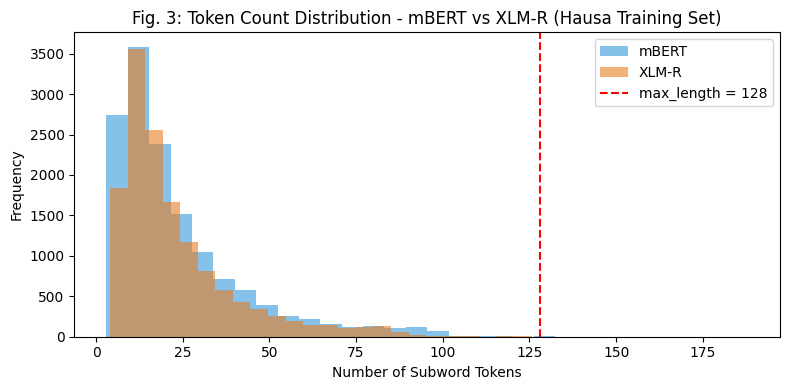

In [21]:
# Plot tokenisation comparison
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mbert_lengths, bins=30, alpha=0.6, label="mBERT", color="#3498db")
ax.hist(xlmr_lengths, bins=30, alpha=0.6, label="XLM-R", color="#e67e22")
ax.axvline(128, color="red", linestyle="--", label="max_length = 128")
ax.set_xlabel("Number of Subword Tokens")
ax.set_ylabel("Frequency")
ax.set_title("Fig. 3: Token Count Distribution - mBERT vs XLM-R (Hausa Training Set)")
ax.legend()
plt.tight_layout()
plt.savefig("tokenizer_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# max_length 128 covers 100% of tweets based on the comparison above.
MAX_LENGTH = 128

class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.encodings = tokenizer(
            texts, max_length=max_length,
            padding="max_length", truncation=True, return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)
        print(f"  Tokenised {len(labels)} samples (max_length={max_length})")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx]
        }

train_texts = train_df["tweet_clean"].tolist()
train_labels = train_df["label_id"].tolist()
val_texts = val_df["tweet_clean"].tolist()
val_labels = val_df["label_id"].tolist()
test_texts = test_df["tweet_clean"].tolist()
test_labels = test_df["label_id"].tolist()

print(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

Train: 14172, Val: 2677, Test: 5303


## Classical Baseline (TF-IDF + Logistic Regression)

Before spending compute on transformers, run a simple non-DL baseline on the same cleaned data. Gives the DL results something concrete to beat.


In [23]:
# Classical baseline: TF-IDF + Logistic Regression, ported from MS1.
# Using the cleaned text (tweet_clean) and integer labels (label_id) so the baseline
# sees the exact same preprocessing as the transformer models. Makes the comparison fair.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X_train_txt = train_df["tweet_clean"].tolist()
X_val_txt   = val_df["tweet_clean"].tolist()
X_test_txt  = test_df["tweet_clean"].tolist()
y_train_int = train_df["label_id"].tolist()
y_val_int   = val_df["label_id"].tolist()
y_test_int  = test_df["label_id"].tolist()

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,
)
X_train_tfidf = vectorizer.fit_transform(X_train_txt)
X_test_tfidf  = vectorizer.transform(X_test_txt)
print(f"TF-IDF feature matrix: {X_train_tfidf.shape}")

lr_clf = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=SEED,
    solver="lbfgs",
)
lr_clf.fit(X_train_tfidf, y_train_int)

y_test_pred = lr_clf.predict(X_test_tfidf)
baseline_results = {
    "accuracy":        accuracy_score(y_test_int, y_test_pred),
    "f1_macro":        f1_score(y_test_int, y_test_pred, average="macro"),
    "precision_macro": precision_score(y_test_int, y_test_pred, average="macro"),
    "recall_macro":    recall_score(y_test_int, y_test_pred, average="macro"),
}

print(f"\nTF-IDF + LogReg (test set):")
for k, v in baseline_results.items():
    print(f"  {k:18s} {v:.4f}")


TF-IDF feature matrix: (14172, 20000)

TF-IDF + LogReg (test set):
  accuracy           0.7430
  f1_macro           0.7445
  precision_macro    0.7499
  recall_macro       0.7429


---
# Milestone 2: Transformer Fine-Tuning

Fine-tune mBERT and XLM-R on the cleaned AfriSenti Hausa data, then run a sequence of experiments (learning rate, loss function, optimiser, longer schedules) to see how far we can push macro F1 beyond the classical baseline.


## Training and Fine-Tuning

In [24]:
# Macro average so each class counts equally regardless of how many examples it has.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro"),
        "recall_macro": recall_score(labels, preds, average="macro"),
    }

In [25]:
# Shared evaluation helper: predict, print metrics, draw the confusion matrix. Used a lot below.
def full_evaluation(trainer, dataset, dataset_name, label_names):
    preds_output = trainer.predict(dataset)
    preds = np.argmax(preds_output.predictions, axis=-1)
    labels = preds_output.label_ids

    print(f"EVALUATION: {dataset_name}\n")
    print(f"Accuracy:        {accuracy_score(labels, preds):.4f}")
    print(f"Macro F1:        {f1_score(labels, preds, average='macro'):.4f}")
    print(f"Macro Precision: {precision_score(labels, preds, average='macro'):.4f}")
    print(f"Macro Recall:    {recall_score(labels, preds, average='macro'):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(labels, preds, target_names=label_names))

    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro"),
        "recall_macro": recall_score(labels, preds, average="macro"),
    }

### Hyperparameters

| Hyperparameter | Value | Justification |
|---------------|-------|---------------|
| Learning rate | 2e-5 | Standard for transformer fine-tuning (Devlin et al., 2019) |
| Batch size | 16 | GPU memory constraint |
| Epochs | 4 | Transformers overfit quickly on small datasets |
| Warmup steps | 350 | ~10% of total steps; stabilises early training |
| Weight decay | 0.01 | L2 regularisation |
| Max seq length | 128 | Covers 100% of tweets based on tokenisation analysis |
| Optimizer | AdamW | Recommended for transformer fine-tuning |
| Loss function | CrossEntropyLoss | Standard for multi-class |

We start with mBERT and XLM-R using these defaults, then tune based on what we find.

### mBERT

In [26]:
mbert_model_name = "bert-base-multilingual-cased"
mbert_model = AutoModelForSequenceClassification.from_pretrained(
    mbert_model_name, num_labels=NUM_LABELS)

total_params = sum(p.numel() for p in mbert_model.parameters())
trainable_params = sum(p.numel() for p in mbert_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

mbert_train_dataset = SentimentDataset(train_texts, train_labels, mbert_tokenizer)
mbert_val_dataset = SentimentDataset(val_texts, val_labels, mbert_tokenizer)
mbert_test_dataset = SentimentDataset(test_texts, test_labels, mbert_tokenizer)

print(f"\nTrain: {len(mbert_train_dataset)}, Val: {len(mbert_val_dataset)}, Test: {len(mbert_test_dataset)}")

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     177,855,747
Trainable parameters: 177,855,747
  Tokenised 14172 samples (max_length=128)
  Tokenised 2677 samples (max_length=128)
  Tokenised 5303 samples (max_length=128)

Train: 14172, Val: 2677, Test: 5303


In [27]:
mbert_training_args = TrainingArguments(
    output_dir="./results_mbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_steps=350,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

mbert_trainer = Trainer(
    model=mbert_model,
    args=mbert_training_args,
    train_dataset=mbert_train_dataset,
    eval_dataset=mbert_val_dataset,
    compute_metrics=compute_metrics,
)

In [28]:
# First real training run.
mbert_train_result = mbert_trainer.train()
print(f"\nmBERT Training Complete!")
print(f"  Loss: {mbert_train_result.training_loss:.4f}")
print(f"  Time: {mbert_train_result.metrics['train_runtime']:.0f}s")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.760466,0.700689,0.703773,0.702909,0.734556,0.703718
2,0.610826,0.627812,0.740755,0.742939,0.750044,0.740868
3,0.461088,0.678415,0.736645,0.735427,0.735801,0.736974
4,0.346467,0.749641,0.748226,0.748038,0.750485,0.748469


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


mBERT Training Complete!
  Loss: 0.5718
  Time: 196s


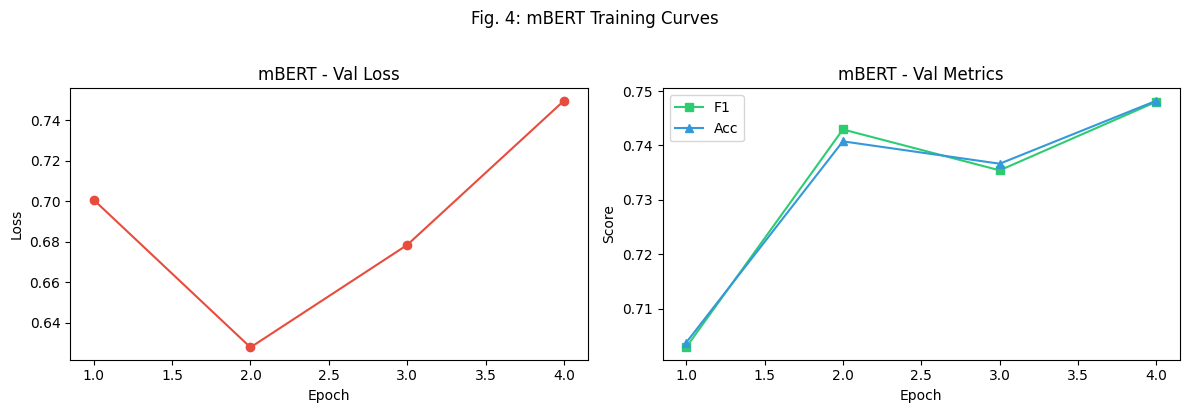


mBERT per-epoch results:
Epoch    Val Loss     Val Acc      Val F1      
1        0.7007       0.7038       0.7029      
2        0.6278       0.7408       0.7429      
3        0.6784       0.7366       0.7354      
4        0.7496       0.7482       0.7480      


In [29]:
mbert_log = mbert_trainer.state.log_history
mbert_eval_entries = [x for x in mbert_log if "eval_loss" in x]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(mbert_eval_entries) + 1)

axes[0].plot(epochs, [x["eval_loss"] for x in mbert_eval_entries], "o-", color="#e74c3c")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("mBERT - Val Loss")

axes[1].plot(epochs, [x["eval_f1_macro"] for x in mbert_eval_entries], "s-", color="#2ecc71", label="F1")
axes[1].plot(epochs, [x["eval_accuracy"] for x in mbert_eval_entries], "^-", color="#3498db", label="Acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score"); axes[1].set_title("mBERT - Val Metrics")
axes[1].legend()

plt.suptitle("Fig. 4: mBERT Training Curves", y=1.02)
plt.tight_layout()
plt.savefig("mbert_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nmBERT per-epoch results:")
print(f"{'Epoch':<8} {'Val Loss':<12} {'Val Acc':<12} {'Val F1':<12}")
for i, entry in enumerate(mbert_eval_entries, 1):
    print(f"{i:<8} {entry['eval_loss']:<12.4f} {entry['eval_accuracy']:<12.4f} {entry['eval_f1_macro']:<12.4f}")

EVALUATION: mBERT - Test Set

Accuracy:        0.7417
Macro F1:        0.7419
Macro Precision: 0.7434
Macro Recall:    0.7418

Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.67      0.70      1759
     neutral       0.68      0.73      0.70      1789
    positive       0.82      0.83      0.82      1755

    accuracy                           0.74      5303
   macro avg       0.74      0.74      0.74      5303
weighted avg       0.74      0.74      0.74      5303



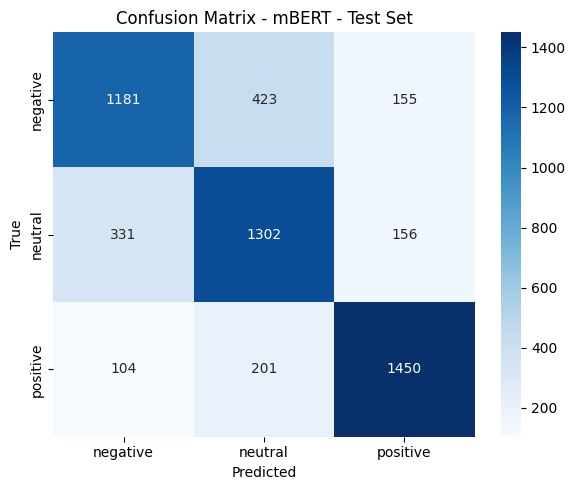

In [30]:
mbert_test_results = full_evaluation(mbert_trainer, mbert_test_dataset, "mBERT - Test Set", LABEL_NAMES)

### XLM-R

In [31]:
xlmr_model_name = "xlm-roberta-base"
xlmr_model = AutoModelForSequenceClassification.from_pretrained(
    xlmr_model_name, num_labels=NUM_LABELS)

total_params = sum(p.numel() for p in xlmr_model.parameters())
print(f"Total parameters: {total_params:,}")

xlmr_train_dataset = SentimentDataset(train_texts, train_labels, xlmr_tokenizer)
xlmr_val_dataset = SentimentDataset(val_texts, val_labels, xlmr_tokenizer)
xlmr_test_dataset = SentimentDataset(test_texts, test_labels, xlmr_tokenizer)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 278,045,955
  Tokenised 14172 samples (max_length=128)
  Tokenised 2677 samples (max_length=128)
  Tokenised 5303 samples (max_length=128)


In [32]:
# Same hyperparameters as mBERT so the two models are compared on equal footing.
xlmr_training_args = TrainingArguments(
    output_dir="./results_xlmr",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_steps=350,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

xlmr_trainer = Trainer(
    model=xlmr_model,
    args=xlmr_training_args,
    train_dataset=xlmr_train_dataset,
    eval_dataset=xlmr_val_dataset,
    compute_metrics=compute_metrics,
)

In [33]:
xlmr_train_result = xlmr_trainer.train()
print(f"\nXLM-R Training Complete!")
print(f"  Loss: {xlmr_train_result.training_loss:.4f}")
print(f"  Time: {xlmr_train_result.metrics['train_runtime']:.0f}s")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.789011,0.724310,0.681360,0.681698,0.700444,0.681504
2,0.625424,0.647371,0.734778,0.736921,0.739996,0.734989
3,0.559967,0.615286,0.744864,0.746527,0.748793,0.745084
4,0.449638,0.640693,0.751588,0.752253,0.755525,0.751789


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


XLM-R Training Complete!
  Loss: 0.6503
  Time: 234s


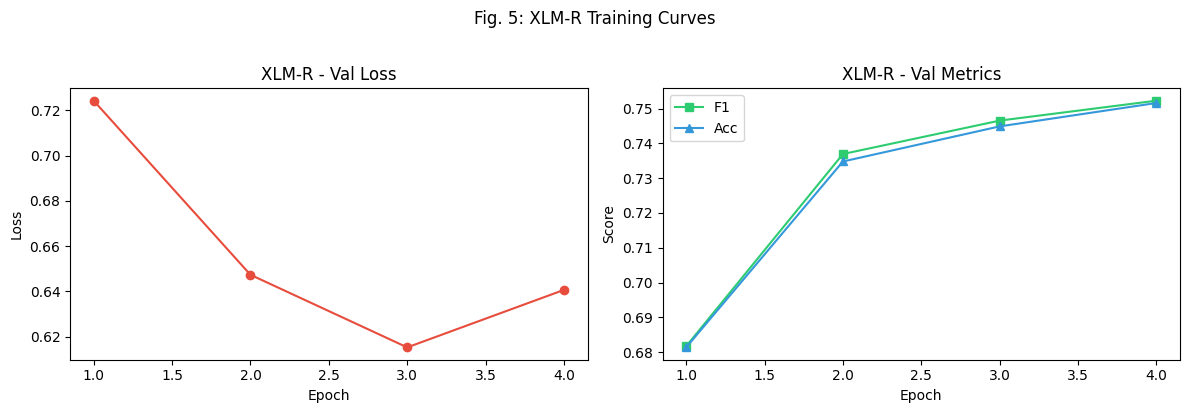


XLM-R per-epoch results:
Epoch    Val Loss     Val Acc      Val F1      
1        0.7243       0.6814       0.6817      
2        0.6474       0.7348       0.7369      
3        0.6153       0.7449       0.7465      
4        0.6407       0.7516       0.7523      


In [34]:
xlmr_log = xlmr_trainer.state.log_history
xlmr_eval_entries = [x for x in xlmr_log if "eval_loss" in x]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(xlmr_eval_entries) + 1)

axes[0].plot(epochs, [x["eval_loss"] for x in xlmr_eval_entries], "o-", color="#e74c3c")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("XLM-R - Val Loss")

axes[1].plot(epochs, [x["eval_f1_macro"] for x in xlmr_eval_entries], "s-", color="#2ecc71", label="F1")
axes[1].plot(epochs, [x["eval_accuracy"] for x in xlmr_eval_entries], "^-", color="#3498db", label="Acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score"); axes[1].set_title("XLM-R - Val Metrics")
axes[1].legend()

plt.suptitle("Fig. 5: XLM-R Training Curves", y=1.02)
plt.tight_layout()
plt.savefig("xlmr_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nXLM-R per-epoch results:")
print(f"{'Epoch':<8} {'Val Loss':<12} {'Val Acc':<12} {'Val F1':<12}")
for i, entry in enumerate(xlmr_eval_entries, 1):
    print(f"{i:<8} {entry['eval_loss']:<12.4f} {entry['eval_accuracy']:<12.4f} {entry['eval_f1_macro']:<12.4f}")

EVALUATION: XLM-R - Test Set

Accuracy:        0.7390
Macro F1:        0.7396
Macro Precision: 0.7401
Macro Recall:    0.7394

Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.72      0.71      1759
     neutral       0.70      0.69      0.69      1789
    positive       0.83      0.81      0.82      1755

    accuracy                           0.74      5303
   macro avg       0.74      0.74      0.74      5303
weighted avg       0.74      0.74      0.74      5303



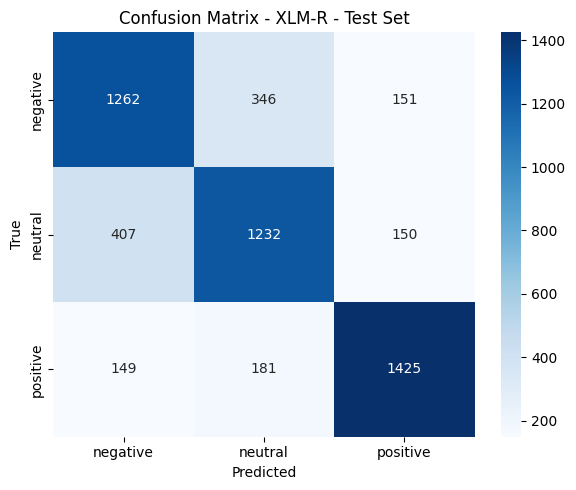

In [35]:
xlmr_test_results = full_evaluation(xlmr_trainer, xlmr_test_dataset, "XLM-R - Test Set", LABEL_NAMES)

### Learning Rate Tuning

In [36]:
# trying different learning rates to see which works best
lr_results = []
learning_rates = [1e-5, 2e-5, 5e-5]

for lr in learning_rates:
    print(f"\n--- Training with LR = {lr} ---")
    model = AutoModelForSequenceClassification.from_pretrained(
        "xlm-roberta-base", num_labels=NUM_LABELS
    )

    args = TrainingArguments(
        output_dir=f"./results_xlmr_lr{lr}",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        learning_rate=lr,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=4,
        weight_decay=0.01,
        warmup_steps=350,  #~10% of total training steps
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_steps=100,
        seed=SEED,
        fp16=torch.cuda.is_available(),
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=xlmr_train_dataset,
        eval_dataset=xlmr_val_dataset,
        compute_metrics=compute_metrics,
    )

    trainer.train()

    # Get best eval results from training log - avoids callback state issues
    eval_entries = [x for x in trainer.state.log_history if "eval_f1_macro" in x]
    best_entry = max(eval_entries, key=lambda x: x["eval_f1_macro"])

    lr_results.append({
        "Learning Rate": lr,
        "Val Loss": round(best_entry["eval_loss"], 4),
        "Val Accuracy": round(best_entry["eval_accuracy"], 4),
        "Val Macro F1": round(best_entry["eval_f1_macro"], 4),
    })
    print(f"  Best Val F1: {best_entry['eval_f1_macro']:.4f}, Val Acc: {best_entry['eval_accuracy']:.4f}")

    # Clean up GPU memory and disk
    del model, trainer
    torch.cuda.empty_cache()
    import shutil, glob
    for d in glob.glob(f"./results_xlmr_lr{lr}/checkpoint-*"):
        shutil.rmtree(d, ignore_errors=True)


--- Training with LR = 1e-05 ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.796230,0.714323,0.686963,0.689578,0.704985,0.687063
2,0.681542,0.659276,0.720209,0.721065,0.724228,0.720551
3,0.595143,0.628818,0.738513,0.739522,0.740980,0.738769
4,0.522932,0.620987,0.739260,0.739765,0.742446,0.739522


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

  Best Val F1: 0.5803, Val Acc: 0.6093


In [37]:
# Pick the learning rate with the best val F1.
lr_df = pd.DataFrame(lr_results)
print(lr_df.to_string(index=False))

best_lr_row = lr_df.loc[lr_df["Val Macro F1"].idxmax()]
print(f"\nBest LR: {best_lr_row['Learning Rate']} (F1={best_lr_row['Val Macro F1']})")

 Learning Rate  Val Loss  Val Accuracy  Val Macro F1
       0.00001    0.6210        0.7393        0.7398
       0.00002    0.6066        0.7546        0.7555
       0.00005    0.7703        0.6093        0.5803

Best LR: 2e-05 (F1=0.7555)


In [38]:
# Clean up to free disk space
import shutil, glob
for d in glob.glob("./results_*/checkpoint-*"):
    shutil.rmtree(d, ignore_errors=True)

### Weighted Loss


Class distribution: {0: 4573, 1: 4912, 2: 4687}
Computed class weights: [1.0330199003219604, 0.9617263674736023, 1.0078941583633423]
  negative (0): 1.0330
  neutral  (1): 0.9617
  positive (2): 1.0079


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.788058,0.716331,0.685095,0.689523,0.697143,0.685329
2,0.649263,0.643575,0.729548,0.730895,0.733295,0.729828
3,0.536845,0.608111,0.747479,0.747983,0.749146,0.747711
4,0.438286,0.640852,0.746731,0.747172,0.750391,0.746957


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Weighted CE Results (best epoch):
  Val Accuracy: 0.7475
  Val Macro F1: 0.7480


EVALUATION: XLM-R (Weighted CE) - Test Set

Accuracy:        0.7245
Macro F1:        0.7248
Macro Precision: 0.7278
Macro Recall:    0.7251

Classification Report:
              precision    recall  f1-score   support

    negative       0.66      0.75      0.70      1759
     neutral       0.70      0.63      0.67      1789
    positive       0.82      0.79      0.80      1755

    accuracy                           0.72      5303
   macro avg       0.73      0.73      0.72      5303
weighted avg       0.73      0.72      0.72      5303



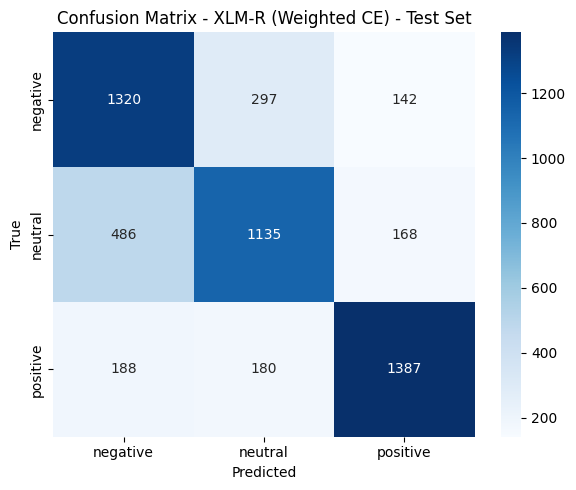

In [39]:
# Calculate class weights (inverse frequency - rarer classes get higher weight)
from collections import Counter
label_counts = Counter(train_labels)
total = len(train_labels)
class_weights = torch.tensor(
    [total / (NUM_LABELS * label_counts[i]) for i in range(NUM_LABELS)],
    dtype=torch.float32
).to(device)

print(f"\nClass distribution: {dict(label_counts)}")
print(f"Computed class weights: {class_weights.tolist()}")
print(f"  negative (0): {class_weights[0]:.4f}")
print(f"  neutral  (1): {class_weights[1]:.4f}")
print(f"  positive (2): {class_weights[2]:.4f}")

# Custom Trainer that uses weighted loss
class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

weighted_model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base", num_labels=NUM_LABELS
)

weighted_args = TrainingArguments(
    output_dir="./results_xlmr_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_steps=350,  #~10% of total training steps
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=100,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

weighted_trainer = WeightedLossTrainer(
    class_weights=class_weights,
    model=weighted_model,
    args=weighted_args,
    train_dataset=xlmr_train_dataset,
    eval_dataset=xlmr_val_dataset,
    compute_metrics=compute_metrics,
)

#Train model
weighted_trainer.train()

#Evaluate - Get best eval results from training log
weighted_eval_entries = [x for x in weighted_trainer.state.log_history if "eval_f1_macro" in x]
weighted_best = max(weighted_eval_entries, key=lambda x: x["eval_f1_macro"])
print(f"\nWeighted CE Results (best epoch):")
print(f"  Val Accuracy: {weighted_best['eval_accuracy']:.4f}")
print(f"  Val Macro F1: {weighted_best['eval_f1_macro']:.4f}")

#Test set evaluation
weighted_test_results = full_evaluation(
    weighted_trainer, xlmr_test_dataset, "XLM-R (Weighted CE) - Test Set", LABEL_NAMES
)

del weighted_model, weighted_trainer
torch.cuda.empty_cache()

In [40]:
for d in glob.glob("./results_*/checkpoint-*"):
    shutil.rmtree(d, ignore_errors=True)
print("Cleaned up old checkpoints.")

Cleaned up old checkpoints.


### SGD vs AdamW

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.962670,0.839721,0.632798,0.620572,0.637782,0.633129
2,0.851619,0.775465,0.651849,0.643328,0.650989,0.652270
3,0.823145,0.754465,0.664923,0.662501,0.666603,0.665258
4,0.790656,0.751085,0.664176,0.659212,0.669969,0.664491


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


SGD Results (best epoch):
  Val Accuracy: 0.6649
  Val Macro F1: 0.6625


EVALUATION: XLM-R (SGD) - Test Set

Accuracy:        0.6081
Macro F1:        0.6107
Macro Precision: 0.6165
Macro Recall:    0.6081

Classification Report:
              precision    recall  f1-score   support

    negative       0.51      0.50      0.50      1759
     neutral       0.55      0.63      0.59      1789
    positive       0.79      0.70      0.74      1755

    accuracy                           0.61      5303
   macro avg       0.62      0.61      0.61      5303
weighted avg       0.62      0.61      0.61      5303



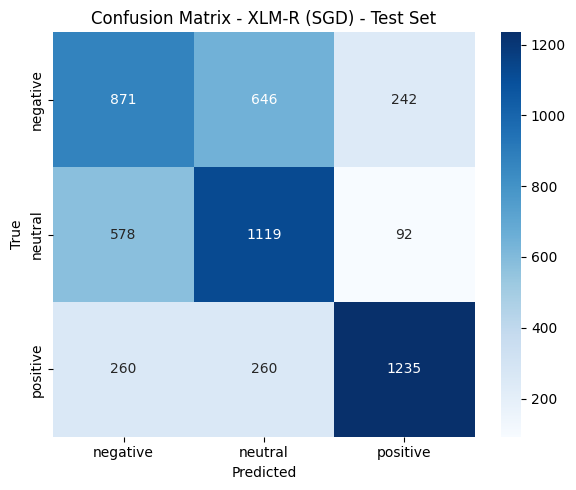

In [41]:
sgd_model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base", num_labels=NUM_LABELS
)

# SGD requires a higher learning rate than AdamW
# Using 5e-4 with momentum=0.9 (defaults for SGD fine-tuning)
sgd_args = TrainingArguments(
    output_dir="./results_xlmr_sgd",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=5e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_steps=350,  #~10% of total training steps
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=100,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
    optim="sgd",
)

#ovveride the optimizer creation to add momentum since sgd has no momentum
from torch.optim import SGD
sgd_trainer = Trainer(
    model=sgd_model,
    args=sgd_args,
    train_dataset=xlmr_train_dataset,
    eval_dataset=xlmr_val_dataset,
    compute_metrics=compute_metrics,
    optimizers=(
        SGD(sgd_model.parameters(), lr=5e-4, momentum=0.9, weight_decay=0.01),
        None
    ),
)

#Train model
sgd_trainer.train()

# Evaluate - Get best eval results from training log
sgd_eval_entries = [x for x in sgd_trainer.state.log_history if "eval_f1_macro" in x]
sgd_best = max(sgd_eval_entries, key=lambda x: x["eval_f1_macro"])
print(f"\nSGD Results (best epoch):")
print(f"  Val Accuracy: {sgd_best['eval_accuracy']:.4f}")
print(f"  Val Macro F1: {sgd_best['eval_f1_macro']:.4f}")

# Test set evaluation
sgd_test_results = full_evaluation(
    sgd_trainer, xlmr_test_dataset, "XLM-R (SGD) - Test Set", LABEL_NAMES
)

# Clean up
del sgd_model, sgd_trainer
torch.cuda.empty_cache()

In [42]:
import shutil, glob
for d in glob.glob("./results_*/checkpoint-*"):
    shutil.rmtree(d, ignore_errors=True)
for d in glob.glob("./results_*/"):
    shutil.rmtree(d, ignore_errors=True)

### Optimised Run


mBERT with LR=5e-5, label_smoothing=0.1, 6 epochs


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Tokenised 14172 samples (max_length=128)
  Tokenised 2677 samples (max_length=128)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.848277,0.824922,0.687337,0.686745,0.715528,0.687131
2,0.732065,0.753045,0.733284,0.735769,0.740861,0.733391
3,0.655607,0.767927,0.727307,0.724648,0.729627,0.727710
4,0.529719,0.794558,0.737019,0.735761,0.735658,0.737352
5,0.461666,0.906709,0.729922,0.733141,0.741170,0.730001
6,0.390176,0.957465,0.738140,0.738286,0.738614,0.738399


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


mBERT Optimised Per-Epoch Results:
Epoch    Val Loss     Val Acc      Val F1      
1        0.8249       0.6873       0.6867      
2        0.7530       0.7333       0.7358      
3        0.7679       0.7273       0.7246      
4        0.7946       0.7370       0.7358      
5        0.9067       0.7299       0.7331      
6        0.9575       0.7381       0.7383      
  Tokenised 5303 samples (max_length=128)


EVALUATION: mBERT Optimised (LR=5e-5) - Test Set

Accuracy:        0.7443
Macro F1:        0.7450
Macro Precision: 0.7459
Macro Recall:    0.7445

Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.71      0.72      1759
     neutral       0.69      0.72      0.70      1789
    positive       0.82      0.81      0.82      1755

    accuracy                           0.74      5303
   macro avg       0.75      0.74      0.74      5303
weighted avg       0.75      0.74      0.74      5303



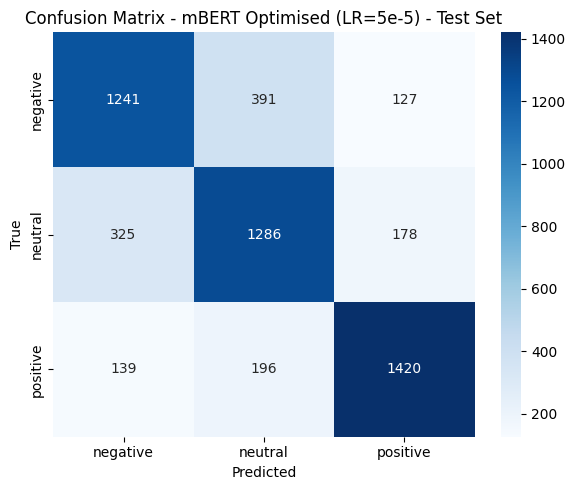


XLM-R with LR=5e-5, label_smoothing=0.1, 6 epochs


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.882839,0.846956,0.650355,0.640602,0.683075,0.650379
2,0.755377,0.748658,0.738513,0.738311,0.743541,0.738750
3,0.713718,0.738490,0.724318,0.724670,0.743029,0.724620
4,0.622511,0.727981,0.746731,0.745217,0.747551,0.747101
5,0.558204,0.737611,0.756817,0.758215,0.761048,0.757020
6,0.496249,0.777101,0.758685,0.759512,0.760301,0.758922


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


XLM-R Optimised Per-Epoch Results:
Epoch    Val Loss     Val Acc      Val F1      
1        0.8470       0.6504       0.6406      
2        0.7487       0.7385       0.7383      
3        0.7385       0.7243       0.7247      
4        0.7280       0.7467       0.7452      
5        0.7376       0.7568       0.7582      
6        0.7771       0.7587       0.7595      


EVALUATION: XLM-R Optimised (LR=5e-5) - Test Set

Accuracy:        0.7371
Macro F1:        0.7377
Macro Precision: 0.7403
Macro Recall:    0.7377

Classification Report:
              precision    recall  f1-score   support

    negative       0.68      0.76      0.72      1759
     neutral       0.71      0.65      0.68      1789
    positive       0.83      0.80      0.82      1755

    accuracy                           0.74      5303
   macro avg       0.74      0.74      0.74      5303
weighted avg       0.74      0.74      0.74      5303



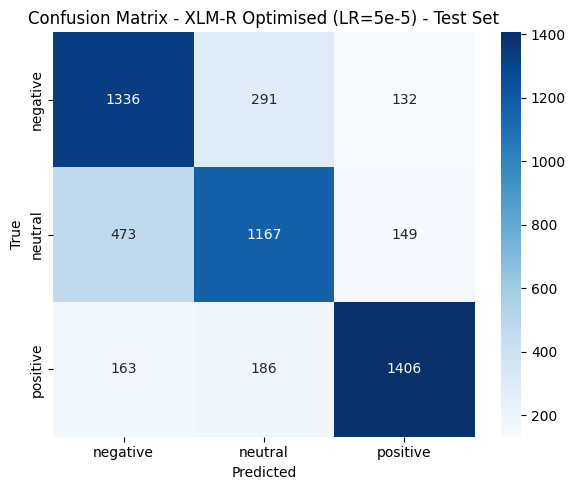

In [43]:
best_results = {}

#mBERT with LR=5e-5
print("\nmBERT with LR=5e-5, label_smoothing=0.1, 6 epochs")
mbert_opt_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-multilingual-cased", num_labels=NUM_LABELS
)

mbert_opt_args = TrainingArguments(
    output_dir="./results_mbert_opt",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=6,
    weight_decay=0.01,
    warmup_steps=350,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
    label_smoothing_factor=0.1,
)

mbert_opt_trainer = Trainer(
    model=mbert_opt_model,
    args=mbert_opt_args,
    train_dataset=SentimentDataset(train_texts, train_labels, mbert_tokenizer),
    eval_dataset=SentimentDataset(val_texts, val_labels, mbert_tokenizer),
    compute_metrics=compute_metrics,
)

#Train Model
mbert_opt_trainer.train()

# Per-epoch results
mbert_opt_eval = [x for x in mbert_opt_trainer.state.log_history if "eval_f1_macro" in x]
print("\nmBERT Optimised Per-Epoch Results:")
print(f"{'Epoch':<8} {'Val Loss':<12} {'Val Acc':<12} {'Val F1':<12}")
for j, entry in enumerate(mbert_opt_eval, 1):
    print(f"{j:<8} {entry['eval_loss']:<12.4f} {entry['eval_accuracy']:<12.4f} {entry['eval_f1_macro']:<12.4f}")

# Test evaluation
mbert_opt_test = full_evaluation(
    mbert_opt_trainer,
    SentimentDataset(test_texts, test_labels, mbert_tokenizer),
    "mBERT Optimised (LR=5e-5) - Test Set", LABEL_NAMES
)
best_results["mBERT_opt"] = mbert_opt_test

del mbert_opt_model, mbert_opt_trainer
torch.cuda.empty_cache()
for d in glob.glob("./results_mbert_opt/checkpoint-*"):
    shutil.rmtree(d, ignore_errors=True)

#XLM-R with LR=5e-5
print("\nXLM-R with LR=5e-5, label_smoothing=0.1, 6 epochs")
xlmr_opt_model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base", num_labels=NUM_LABELS
)

xlmr_opt_args = TrainingArguments(
    output_dir="./results_xlmr_opt",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=6,
    weight_decay=0.01,
    warmup_steps=350,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
    label_smoothing_factor=0.1,
)

xlmr_opt_trainer = Trainer(
    model=xlmr_opt_model,
    args=xlmr_opt_args,
    train_dataset=xlmr_train_dataset,
    eval_dataset=xlmr_val_dataset,
    compute_metrics=compute_metrics,
)

xlmr_opt_trainer.train()

# Per-epoch results
xlmr_opt_eval = [x for x in xlmr_opt_trainer.state.log_history if "eval_f1_macro" in x]
print("\nXLM-R Optimised Per-Epoch Results:")
print(f"{'Epoch':<8} {'Val Loss':<12} {'Val Acc':<12} {'Val F1':<12}")
for j, entry in enumerate(xlmr_opt_eval, 1):
    print(f"{j:<8} {entry['eval_loss']:<12.4f} {entry['eval_accuracy']:<12.4f} {entry['eval_f1_macro']:<12.4f}")

# Test evaluation
xlmr_opt_test = full_evaluation(
    xlmr_opt_trainer,
    xlmr_test_dataset,
    "XLM-R Optimised (LR=5e-5) - Test Set", LABEL_NAMES
)
best_results["XLM-R_opt"] = xlmr_opt_test

del xlmr_opt_model, xlmr_opt_trainer
torch.cuda.empty_cache()

### Max Performance


Using max_length=64 (reduced from 128)
mBERT - Maximum Performance


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Tokenised 14172 samples (max_length=64)
  Tokenised 2677 samples (max_length=64)
  Tokenised 5303 samples (max_length=64)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,1.717535,0.804031,0.680986,0.686105,0.703340,0.680977
2,1.476978,0.756304,0.726933,0.730433,0.754751,0.726817
3,1.275266,0.755605,0.744490,0.742931,0.743050,0.744848
4,1.017230,0.776282,0.747105,0.747285,0.748415,0.747340
5,0.869001,0.851861,0.740007,0.742232,0.749148,0.740106
6,0.724570,0.926010,0.751214,0.751688,0.754431,0.751412
7,0.671117,0.952501,0.750840,0.750966,0.751423,0.751083
8,0.669260,0.960610,0.753455,0.753517,0.754584,0.753691


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


mBERT Max Performance - Per-Epoch Results:
Epoch    Val Loss     Val Acc      Val F1      
1        0.8040       0.6810       0.6861      
2        0.7563       0.7269       0.7304      
3        0.7556       0.7445       0.7429      
4        0.7763       0.7471       0.7473      
5        0.8519       0.7400       0.7422      
6        0.9260       0.7512       0.7517      
7        0.9525       0.7508       0.7510      
8        0.9606       0.7535       0.7535      


EVALUATION: mBERT Max Performance - Test Set

Accuracy:        0.7469
Macro F1:        0.7469
Macro Precision: 0.7466
Macro Recall:    0.7473

Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.72      0.72      1759
     neutral       0.70      0.69      0.70      1789
    positive       0.81      0.83      0.82      1755

    accuracy                           0.75      5303
   macro avg       0.75      0.75      0.75      5303
weighted avg       0.75      0.75      0.75      5303



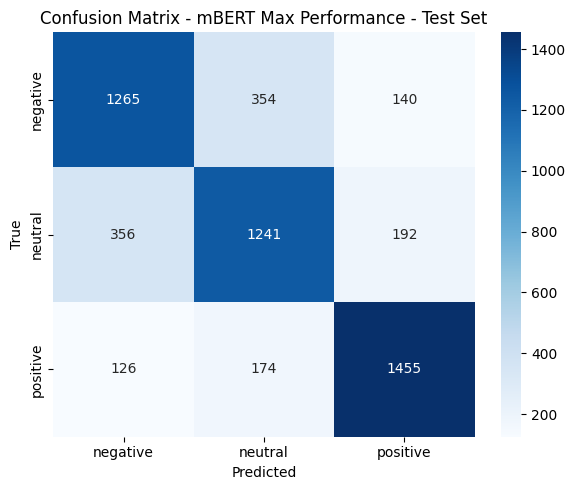

7b: XLM-R - Maximum Performance


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Tokenised 14172 samples (max_length=64)
  Tokenised 2677 samples (max_length=64)
  Tokenised 5303 samples (max_length=64)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,1.783183,0.917341,0.595816,0.601699,0.618229,0.595966
2,1.574532,0.778389,0.719089,0.719595,0.726022,0.719269
3,1.489006,0.753809,0.720209,0.722908,0.727821,0.720405
4,1.289675,0.705693,0.747852,0.749138,0.750946,0.748094
5,1.212020,0.722021,0.755323,0.756288,0.757529,0.755561
6,1.051867,0.764163,0.752335,0.753331,0.754494,0.752566
7,0.997817,0.786317,0.749346,0.750031,0.751003,0.749590
8,0.985579,0.787529,0.750840,0.751323,0.751550,0.751115


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


XLM-R Max Performance - Per-Epoch Results:
Epoch    Val Loss     Val Acc      Val F1      
1        0.9173       0.5958       0.6017      
2        0.7784       0.7191       0.7196      
3        0.7538       0.7202       0.7229      
4        0.7057       0.7479       0.7491      
5        0.7220       0.7553       0.7563      
6        0.7642       0.7523       0.7533      
7        0.7863       0.7493       0.7500      
8        0.7875       0.7508       0.7513      


EVALUATION: XLM-R Max Performance - Test Set

Accuracy:        0.7422
Macro F1:        0.7430
Macro Precision: 0.7463
Macro Recall:    0.7428

Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.76      0.72      1759
     neutral       0.72      0.66      0.69      1789
    positive       0.84      0.81      0.83      1755

    accuracy                           0.74      5303
   macro avg       0.75      0.74      0.74      5303
weighted avg       0.75      0.74      0.74      5303



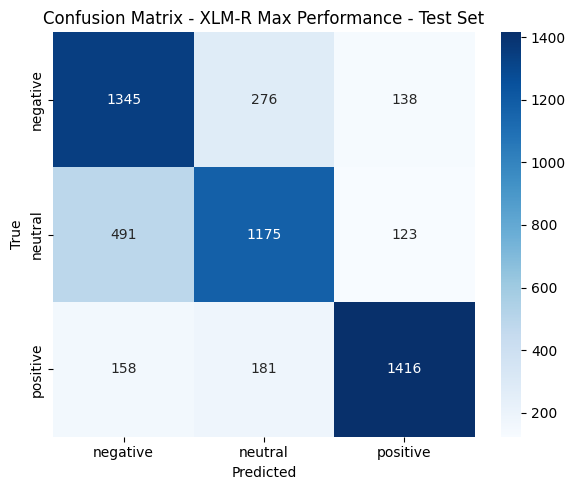

In [44]:
import shutil, glob
for d in glob.glob("./results_*/"):
    shutil.rmtree(d, ignore_errors=True)

# Re-create datasets with max_length=64 (less padding = less noise)
MAX_LENGTH_OPT = 64
print(f"\nUsing max_length={MAX_LENGTH_OPT} (reduced from 128)")
max_perf_results = {}

#mBERT Maximum Performance
print("mBERT - Maximum Performance")
mbert_max_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-multilingual-cased", num_labels=NUM_LABELS
)

# Create datasets with max_length=64
mbert_max_train = SentimentDataset(train_texts, train_labels, mbert_tokenizer, max_length=MAX_LENGTH_OPT)
mbert_max_val = SentimentDataset(val_texts, val_labels, mbert_tokenizer, max_length=MAX_LENGTH_OPT)
mbert_max_test = SentimentDataset(test_texts, test_labels, mbert_tokenizer, max_length=MAX_LENGTH_OPT)

mbert_max_args = TrainingArguments(
    output_dir="./results_mbert_max",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,  #effective batch size = 32
    num_train_epochs=8,
    weight_decay=0.01,
    warmup_steps=200,
    lr_scheduler_type="cosine",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
    label_smoothing_factor=0.1,
)

mbert_max_trainer = Trainer(
    model=mbert_max_model,
    args=mbert_max_args,
    train_dataset=mbert_max_train,
    eval_dataset=mbert_max_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

mbert_max_trainer.train()

# Per-epoch results
mbert_max_eval = [x for x in mbert_max_trainer.state.log_history if "eval_f1_macro" in x]
print("\nmBERT Max Performance - Per-Epoch Results:")
print(f"{'Epoch':<8} {'Val Loss':<12} {'Val Acc':<12} {'Val F1':<12}")
for j, entry in enumerate(mbert_max_eval, 1):
    print(f"{j:<8} {entry['eval_loss']:<12.4f} {entry['eval_accuracy']:<12.4f} {entry['eval_f1_macro']:<12.4f}")

# Test evaluation
mbert_max_test_results = full_evaluation(
    mbert_max_trainer, mbert_max_test,
    "mBERT Max Performance - Test Set", LABEL_NAMES
)
max_perf_results["mBERT_max"] = mbert_max_test_results

del mbert_max_model, mbert_max_trainer
torch.cuda.empty_cache()
for d in glob.glob("./results_mbert_max/checkpoint-*"):
    shutil.rmtree(d, ignore_errors=True)

#XLM-R Maximum Performance
print("7b: XLM-R - Maximum Performance")
xlmr_max_model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base", num_labels=NUM_LABELS
)

# Create datasets with max_length=64
xlmr_max_train = SentimentDataset(train_texts, train_labels, xlmr_tokenizer, max_length=MAX_LENGTH_OPT)
xlmr_max_val = SentimentDataset(val_texts, val_labels, xlmr_tokenizer, max_length=MAX_LENGTH_OPT)
xlmr_max_test = SentimentDataset(test_texts, test_labels, xlmr_tokenizer, max_length=MAX_LENGTH_OPT)

xlmr_max_args = TrainingArguments(
    output_dir="./results_xlmr_max",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    num_train_epochs=8,
    weight_decay=0.01,
    warmup_steps=200,
    lr_scheduler_type="cosine",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
    label_smoothing_factor=0.1,
)

xlmr_max_trainer = Trainer(
    model=xlmr_max_model,
    args=xlmr_max_args,
    train_dataset=xlmr_max_train,
    eval_dataset=xlmr_max_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

xlmr_max_trainer.train()

# Per-epoch results
xlmr_max_eval = [x for x in xlmr_max_trainer.state.log_history if "eval_f1_macro" in x]
print("\nXLM-R Max Performance - Per-Epoch Results:")
print(f"{'Epoch':<8} {'Val Loss':<12} {'Val Acc':<12} {'Val F1':<12}")
for j, entry in enumerate(xlmr_max_eval, 1):
    print(f"{j:<8} {entry['eval_loss']:<12.4f} {entry['eval_accuracy']:<12.4f} {entry['eval_f1_macro']:<12.4f}")

# Test evaluation
xlmr_max_test_results = full_evaluation(
    xlmr_max_trainer, xlmr_max_test,
    "XLM-R Max Performance - Test Set", LABEL_NAMES
)
max_perf_results["XLM-R_max"] = xlmr_max_test_results

del xlmr_max_model, xlmr_max_trainer
torch.cuda.empty_cache()

## Results Summary and Comparison

In [45]:
# Pulling every experiment into one table. Easier to reason about once everything is side by side.
# Building it from a list of (name, results_dict) tuples so I'm not copy-pasting 9 near-identical blocks.
experiments = [
    ("TF-IDF + Logistic Regression (baseline)",        baseline_results),
    ("mBERT (AdamW, CE, LR=2e-5)",                     mbert_test_results),
    ("XLM-R (AdamW, CE, LR=2e-5)",                     xlmr_test_results),
    ("XLM-R (AdamW, Weighted CE, LR=2e-5)",            weighted_test_results),
    ("XLM-R (SGD, CE, LR=5e-4)",                       sgd_test_results),
    ("mBERT (Optimised: LR=5e-5, smoothing=0.1)",      best_results["mBERT_opt"]),
    ("XLM-R (Optimised: LR=5e-5, smoothing=0.1)",      best_results["XLM-R_opt"]),
    ("mBERT (MAX: LR=5e-5, cos, grad_accum, seq=64)",  max_perf_results["mBERT_max"]),
    ("XLM-R (MAX: LR=5e-5, cos, grad_accum, seq=64)",  max_perf_results["XLM-R_max"]),
]

results_df = pd.DataFrame([
    {
        "Model": name,
        "Test Accuracy":  round(r["accuracy"], 4),
        "Test Macro F1":  round(r["f1_macro"], 4),
        "Test Precision": round(r["precision_macro"], 4),
        "Test Recall":    round(r["recall_macro"], 4),
    }
    for name, r in experiments
])

print("TABLE 1: RESULTS COMPARISON - ALL MODELS & EXPERIMENTS")
print(results_df.to_string(index=False))

best_idx = results_df["Test Macro F1"].idxmax()
baseline_f1 = baseline_results["f1_macro"]
best_f1 = results_df.loc[best_idx, "Test Macro F1"]
improvement = best_f1 - baseline_f1

print(f"\nBest model: {results_df.loc[best_idx, 'Model']}")
print(f"  Test Macro F1: {best_f1}")
print(f"  Improvement over baseline: +{improvement:.4f} F1 ({improvement/baseline_f1*100:.1f}% relative)")

# Print just the numbers for the three comparisons. Interpretation goes in the report.
mbert_f1    = results_df.iloc[1]["Test Macro F1"]
xlmr_f1     = results_df.iloc[2]["Test Macro F1"]
weighted_f1 = results_df.iloc[3]["Test Macro F1"]
sgd_f1      = results_df.iloc[4]["Test Macro F1"]

print("\nSide-by-side F1 numbers for the report:")
print(f"  mBERT vs XLM-R (arch):         {mbert_f1:.4f} vs {xlmr_f1:.4f}   (delta {xlmr_f1 - mbert_f1:+.4f})")
print(f"  CE vs Weighted CE (loss):      {xlmr_f1:.4f} vs {weighted_f1:.4f}   (delta {weighted_f1 - xlmr_f1:+.4f})")
print(f"  AdamW vs SGD (optimizer):      {xlmr_f1:.4f} vs {sgd_f1:.4f}   (delta {sgd_f1 - xlmr_f1:+.4f})")


TABLE 1: RESULTS COMPARISON - ALL MODELS & EXPERIMENTS
                                        Model  Test Accuracy  Test Macro F1  Test Precision  Test Recall
      TF-IDF + Logistic Regression (baseline)         0.7430         0.7445          0.7499       0.7429
                   mBERT (AdamW, CE, LR=2e-5)         0.7417         0.7419          0.7434       0.7418
                   XLM-R (AdamW, CE, LR=2e-5)         0.7390         0.7396          0.7401       0.7394
          XLM-R (AdamW, Weighted CE, LR=2e-5)         0.7245         0.7248          0.7278       0.7251
                     XLM-R (SGD, CE, LR=5e-4)         0.6081         0.6107          0.6165       0.6081
    mBERT (Optimised: LR=5e-5, smoothing=0.1)         0.7443         0.7450          0.7459       0.7445
    XLM-R (Optimised: LR=5e-5, smoothing=0.1)         0.7371         0.7377          0.7403       0.7377
mBERT (MAX: LR=5e-5, cos, grad_accum, seq=64)         0.7469         0.7469          0.7466       0.7473


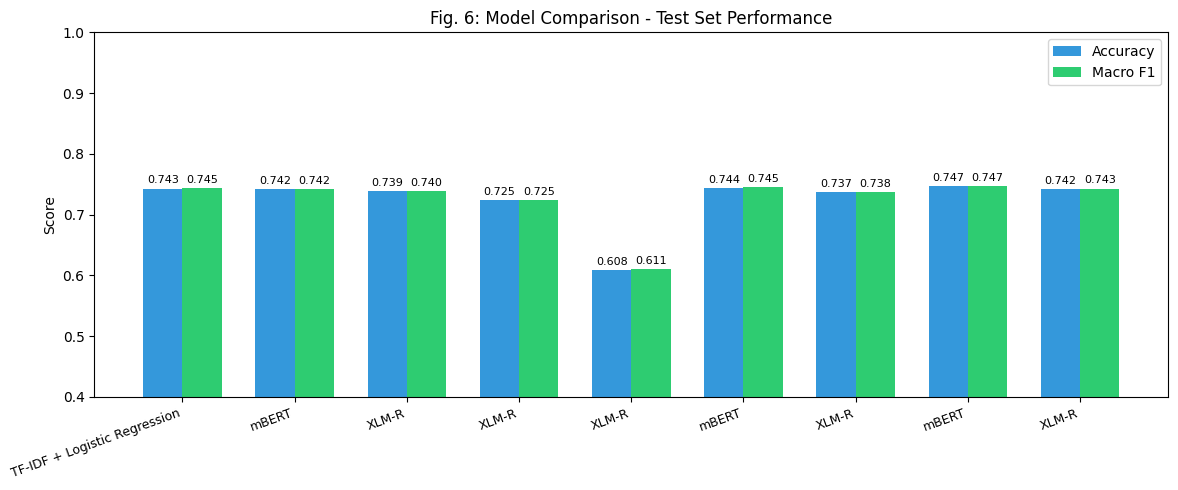

In [46]:
fig, ax = plt.subplots(figsize=(12, 5))
models = results_df["Model"].tolist()
x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, results_df["Test Accuracy"], width, label="Accuracy", color="#3498db")
bars2 = ax.bar(x + width/2, results_df["Test Macro F1"], width, label="Macro F1", color="#2ecc71")

ax.set_ylabel("Score")
ax.set_title("Fig. 6: Model Comparison - Test Set Performance")
ax.set_xticks(x)
ax.set_xticklabels([m.split(" (")[0] for m in models], rotation=20, ha="right", fontsize=9)
ax.legend()
ax.set_ylim(0.4, 1.0)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [47]:
print(f"\nResults:")
print(results_df.to_string(index=False))
print(f"\nBest model: {results_df.loc[best_idx, 'Model']}")
print(f"Improvement over baseline: +{improvement:.4f} Macro F1")


Results:
                                        Model  Test Accuracy  Test Macro F1  Test Precision  Test Recall
      TF-IDF + Logistic Regression (baseline)         0.7430         0.7445          0.7499       0.7429
                   mBERT (AdamW, CE, LR=2e-5)         0.7417         0.7419          0.7434       0.7418
                   XLM-R (AdamW, CE, LR=2e-5)         0.7390         0.7396          0.7401       0.7394
          XLM-R (AdamW, Weighted CE, LR=2e-5)         0.7245         0.7248          0.7278       0.7251
                     XLM-R (SGD, CE, LR=5e-4)         0.6081         0.6107          0.6165       0.6081
    mBERT (Optimised: LR=5e-5, smoothing=0.1)         0.7443         0.7450          0.7459       0.7445
    XLM-R (Optimised: LR=5e-5, smoothing=0.1)         0.7371         0.7377          0.7403       0.7377
mBERT (MAX: LR=5e-5, cos, grad_accum, seq=64)         0.7469         0.7469          0.7466       0.7473
XLM-R (MAX: LR=5e-5, cos, grad_accum, seq=64)

---
# Milestone 3: Testing on New Data + Deployment

Milestone 2 compared mBERT and XLM-R across several configurations (see Table 1 above). For Milestone 3 we pick **XLM-R MAX** as the deployment model — XLM-R's cross-lingual pre-training is the more relevant backbone for the cross-domain generalisation test that follows. We (1) reproduce that model, (2) test it on a truly unseen Hausa corpus (**NollySenti**, movie reviews) to check domain generalisation, and (3) deploy it as a Gradio web app.


In [48]:
# For MS3 we deploy the XLM-R MAX config (same hyperparameters as Milestone 2). Retraining it here so the model is in memory for the NollySenti evaluation and the Gradio push below.
import shutil, glob
for d in glob.glob("./results_final/"):
    shutil.rmtree(d, ignore_errors=True)

best_model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base", num_labels=NUM_LABELS
)

best_train = SentimentDataset(train_texts, train_labels, xlmr_tokenizer, max_length=64)
best_val   = SentimentDataset(val_texts,   val_labels,   xlmr_tokenizer, max_length=64)
best_test  = SentimentDataset(test_texts,  test_labels,  xlmr_tokenizer, max_length=64)

best_args = TrainingArguments(
    output_dir="./results_final",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    num_train_epochs=8,
    weight_decay=0.01,
    warmup_steps=200,
    lr_scheduler_type="cosine",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
    label_smoothing_factor=0.1,
)

best_trainer = Trainer(
    model=best_model,
    args=best_args,
    train_dataset=best_train,
    eval_dataset=best_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

best_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Tokenised 14172 samples (max_length=64)
  Tokenised 2677 samples (max_length=64)
  Tokenised 5303 samples (max_length=64)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,1.783183,0.917341,0.595816,0.601699,0.618229,0.595966
2,1.574532,0.778389,0.719089,0.719595,0.726022,0.719269
3,1.489006,0.753809,0.720209,0.722908,0.727821,0.720405
4,1.289675,0.705693,0.747852,0.749138,0.750946,0.748094
5,1.212020,0.722021,0.755323,0.756288,0.757529,0.755561
6,1.051867,0.764163,0.752335,0.753331,0.754494,0.752566
7,0.997817,0.786317,0.749346,0.750031,0.751003,0.749590
8,0.985579,0.787529,0.750840,0.751323,0.751550,0.751115


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=3544, training_loss=1.339600839679451, metrics={'train_runtime': 418.3494, 'train_samples_per_second': 271.008, 'train_steps_per_second': 8.471, 'total_flos': 3728843356041216.0, 'train_loss': 1.339600839679451, 'epoch': 8.0})

In [49]:
# Save model + tokenizer so the Gradio cell can reload them without needing the Trainer
SAVE_DIR = "./best_model"
best_trainer.save_model(SAVE_DIR)
xlmr_tokenizer.save_pretrained(SAVE_DIR)
print(f"Saved to {SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to ./best_model


EVALUATION: AfriSenti Hausa — Test Split (MS3 recap)

Accuracy:        0.7422
Macro F1:        0.7430
Macro Precision: 0.7463
Macro Recall:    0.7428

Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.76      0.72      1759
     neutral       0.72      0.66      0.69      1789
    positive       0.84      0.81      0.83      1755

    accuracy                           0.74      5303
   macro avg       0.75      0.74      0.74      5303
weighted avg       0.75      0.74      0.74      5303



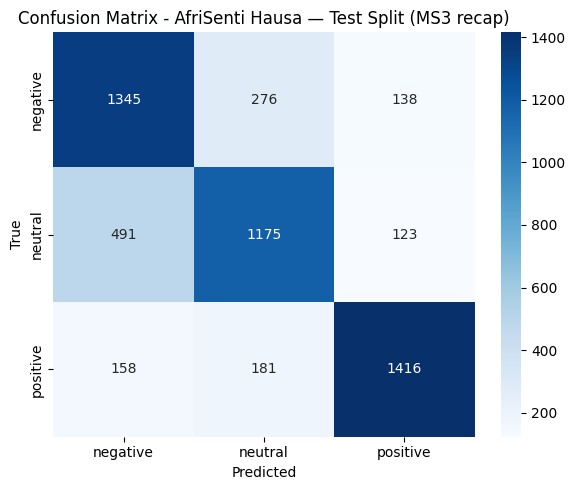

In [50]:
afrisenti_results = full_evaluation(
    best_trainer, best_test,
    "AfriSenti Hausa — Test Split (MS3 recap)", LABEL_NAMES
)

In [51]:
# Brand new corpus. Movie reviews in Hausa, not tweets - so this is a genuine domain shift.
from datasets import load_dataset

# Real HF path for NollySenti (Shode et al., ACL 2023)
nollysenti = load_dataset("Davlan/nollysenti", "ha")
print(nollysenti)
print("\nFirst example:")
print(nollysenti["train"][0])

README.md: 0.00B [00:00, ?B/s]

train.tsv: 0.00B [00:00, ?B/s]

dev.tsv: 0.00B [00:00, ?B/s]

test.tsv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['ha_review', 'sentiment'],
        num_rows: 410
    })
    validation: Dataset({
        features: ['ha_review', 'sentiment'],
        num_rows: 100
    })
    test: Dataset({
        features: ['ha_review', 'sentiment'],
        num_rows: 500
    })
})

First example:
{'ha_review': 'Soap opera mai tashe dake warwarewa akan backdrop na darasin gargaɗin tahiri dake tunatar damu cewa a Najeriya, iya yawan abubuwa da suka sauya, iya yawan da zasu tsaya da hauka. ', 'sentiment': 'positive'}


In [52]:
# Flatten all splits into one evaluation set (we're using it as a test set, not training)
nolly_frames = [nollysenti[s].to_pandas() for s in nollysenti.keys()]
nolly_df = pd.concat(nolly_frames, ignore_index=True)

print(f"Columns: {list(nolly_df.columns)}")
print(f"Total rows: {len(nolly_df)}")
print(f"\nLabel distribution:\n{nolly_df.iloc[:, -1].value_counts()}")
nolly_df.head(3)

Columns: ['ha_review', 'sentiment']
Total rows: 1010

Label distribution:
sentiment
negative    510
positive    500
Name: count, dtype: int64


,ha_review,sentiment
0,Soap opera mai tashe dake warwarewa akan backd...,positive
1,Aiki mai matuƙar yawa da tantancewa ya tafi zu...,positive
2,My village people shiri ne da zai saka ka rasa...,positive


In [53]:
# NollySenti Hausa columns: ha_review (text), sentiment (positive/negative)
nolly_df["text"] = nolly_df["ha_review"].astype(str).map(clean_tweet)

# Normalise labels to {0: negative, 1: positive}
nolly_df["bin_label"] = nolly_df["sentiment"].str.lower().str.strip().map(
    {"negative": 0, "positive": 1}
)
nolly_df = nolly_df.dropna(subset=["bin_label"]).reset_index(drop=True)
nolly_df["bin_label"] = nolly_df["bin_label"].astype(int)

print(f"Rows: {len(nolly_df)}")
print(f"Label distribution: {nolly_df['bin_label'].value_counts().to_dict()}")

Rows: 1010
Label distribution: {0: 510, 1: 500}


NollySenti Hausa — Binary Evaluation

Accuracy:  0.6604
Macro F1:  0.6604
Precision: 0.6604
Recall:    0.6604

Classification report:
              precision    recall  f1-score   support

    negative       0.67      0.66      0.66       510
    positive       0.65      0.66      0.66       500

    accuracy                           0.66      1010
   macro avg       0.66      0.66      0.66      1010
weighted avg       0.66      0.66      0.66      1010



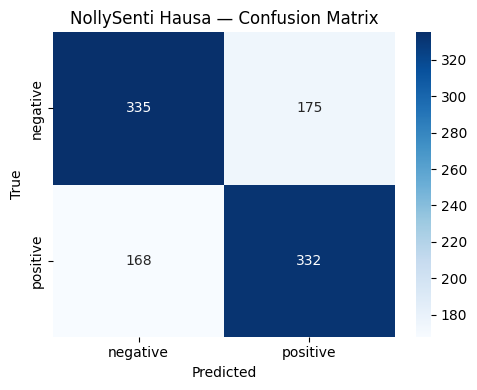

In [54]:
# Running inference manually here because NollySenti labels are binary but my model outputs 3 classes.
# Tokenise NollySenti text with the same tokenizer and max_length used for training
nolly_enc = xlmr_tokenizer(
    nolly_df["text"].tolist(),
    max_length=64, padding="max_length", truncation=True, return_tensors="pt"
)

# Use the underlying model directly (no labels to feed to Trainer.predict)
best_model.eval()
logits_all = []
with torch.no_grad():
    B = 32
    for i in range(0, len(nolly_df), B):
        batch = {k: v[i:i+B].to(device) for k, v in nolly_enc.items()}
        out = best_model(**batch)
        logits_all.append(out.logits.detach().cpu())
logits = torch.cat(logits_all, dim=0).numpy()

# Binary prediction: compare neg (class 0) vs pos (class 2), skip neutral (class 1)
bin_preds = (logits[:, 2] > logits[:, 0]).astype(int)    # 1 = positive, 0 = negative
nolly_df["pred"] = bin_preds
nolly_df["neutral_logit"] = logits[:, 1]

gold = nolly_df["bin_label"].values
print("NollySenti Hausa — Binary Evaluation\n")
print(f"Accuracy:  {accuracy_score(gold, bin_preds):.4f}")
print(f"Macro F1:  {f1_score(gold, bin_preds, average='macro'):.4f}")
print(f"Precision: {precision_score(gold, bin_preds, average='macro'):.4f}")
print(f"Recall:    {recall_score(gold, bin_preds, average='macro'):.4f}")
print(f"\nClassification report:")
print(classification_report(gold, bin_preds, target_names=["negative", "positive"]))

cm = confusion_matrix(gold, bin_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "positive"], yticklabels=["negative", "positive"])
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("NollySenti Hausa — Confusion Matrix")
plt.tight_layout(); plt.show()

nolly_results = {
    "accuracy":  accuracy_score(gold, bin_preds),
    "f1_macro":  f1_score(gold, bin_preds, average='macro'),
    "precision_macro": precision_score(gold, bin_preds, average='macro'),
    "recall_macro":    recall_score(gold, bin_preds, average='macro'),
}

In [55]:
# Show BOTH error directions, not just the first 15 (rows are ordered, so head(15)
# was only sampling one failure mode). Stratified sample: up to 8 from each type.
label_name = {0: "negative", 1: "positive"}
nolly_df["correct"] = nolly_df["pred"] == nolly_df["bin_label"]

wrong = nolly_df[~nolly_df["correct"]]
pos_as_neg = wrong[(wrong["bin_label"] == 1) & (wrong["pred"] == 0)].sample(
    n=min(8, len(wrong[(wrong["bin_label"] == 1) & (wrong["pred"] == 0)])),
    random_state=SEED
)
neg_as_pos = wrong[(wrong["bin_label"] == 0) & (wrong["pred"] == 1)].sample(
    n=min(8, len(wrong[(wrong["bin_label"] == 0) & (wrong["pred"] == 1)])),
    random_state=SEED
)

n_pos_as_neg = (wrong["bin_label"] == 1).sum()
n_neg_as_pos = (wrong["bin_label"] == 0).sum()
print(f"Total misclassified: {len(wrong)} / {len(nolly_df)}")
print(f"  positive->negative errors: {n_pos_as_neg}")
print(f"  negative->positive errors: {n_neg_as_pos}\n")

for section_name, subset in [("positive -> negative errors", pos_as_neg),
                              ("negative -> positive errors", neg_as_pos)]:
    print(f"=== {section_name} (showing {len(subset)}) ===\n")
    for _, r in subset.iterrows():
        txt = r["text"][:160] + ("..." if len(r["text"]) > 160 else "")
        print(f"TEXT : {txt}")
        print(f"GOLD : {label_name[r['bin_label']]}   PRED: {label_name[r['pred']]}   (neutral_logit={r['neutral_logit']:+.2f})")
        print("-" * 70)
    print()

Total misclassified: 343 / 1010
  positive->negative errors: 168
  negative->positive errors: 175

=== positive -> negative errors (showing 8) ===

TEXT : Labarin Mama Drama ya zama kamar gilashin ruwan inibi da ba kasafai ake samu ba mai shaƙatarwa, wani abu daban kuma sabon. Yana tura ambulaf.
GOLD : positive   PRED: negative   (neutral_logit=+0.64)
----------------------------------------------------------------------
TEXT : Temi Otedola tayi aikin ban mamaki!
GOLD : positive   PRED: negative   (neutral_logit=+1.54)
----------------------------------------------------------------------
TEXT : A sauƙaƙe dangantakan ruwayar Andrew DosunDoorge na wasan kwaikwayon baƙin haure masu tada sha'awa Mahaifiyar George zata yi abu kadan don isar da tsurar shirin...
GOLD : positive   PRED: negative   (neutral_logit=+0.40)
----------------------------------------------------------------------
TEXT : Babban shiri daga Nollywood.. . . . Ba'a rubuta Lionheart kawai don shi ba. Ya nuna abubuwa dayawa

In [56]:
# Reload from disk so this cell still works even if the trainer has been garbage-collected.
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

deploy_tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
deploy_model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(device).eval()

def predict_sentiment(text):
    text = clean_tweet(text or "")
    if not text:
        return {n: 0.0 for n in LABEL_NAMES}
    enc = deploy_tokenizer(text, max_length=64, padding="max_length",
                           truncation=True, return_tensors="pt").to(device)
    with torch.no_grad():
        probs = F.softmax(deploy_model(**enc).logits, dim=-1)[0].cpu().tolist()
    return {LABEL_NAMES[i]: float(probs[i]) for i in range(NUM_LABELS)}

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [57]:
# Five quick examples to confirm the reloaded model still predicts before pushing anything to the Hub.
short = nolly_df[nolly_df["text"].str.len().between(30, 120)]
verification_samples = pd.concat([
    short[short["bin_label"] == 1].head(3),
    short[short["bin_label"] == 0].head(2),
]).reset_index(drop=True)

gold_name = {0: "negative", 1: "positive"}
hits = 0
for _, row in verification_samples.iterrows():
    text = row["text"]
    gold = gold_name[row["bin_label"]]
    scores = predict_sentiment(text)
    # Collapse the 3-class output to a binary decision to compare with NollySenti's binary label
    binary_pred = "positive" if scores["positive"] > scores["negative"] else "negative"
    match = "OK" if binary_pred == gold else "MISMATCH"
    if binary_pred == gold:
        hits += 1

    print(f"INPUT : {text[:140]}{'...' if len(text) > 140 else ''}")
    print(f"GOLD  : {gold} (NollySenti-annotated)")
    print(f"PRED  : {binary_pred}  [{match}]")
    print(f"SCORES: " + ", ".join(f"{k}={v:.2f}" for k, v in scores.items()))
    print("-" * 70)

print(f"\nSmoke-test summary: {hits}/{len(verification_samples)} correct")

INPUT : Shekarun1980, masu sufurin ƙwaya, kyawawan baƙaƙen mata ... Ina cikin aljanna
GOLD  : positive (NollySenti-annotated)
PRED  : positive  [OK]
SCORES: negative=0.22, neutral=0.24, positive=0.54
----------------------------------------------------------------------
INPUT : wannan shirin kyauta ce mai kyau a cikin nau'in.
GOLD  : positive (NollySenti-annotated)
PRED  : positive  [OK]
SCORES: negative=0.23, neutral=0.41, positive=0.36
----------------------------------------------------------------------
INPUT : Ambato shirin. . Cikakken shiri. Naso dukkan daƙiƙa ma shirin. Nayi fatan bai ƙare ba.
GOLD  : positive (NollySenti-annotated)
PRED  : positive  [OK]
SCORES: negative=0.07, neutral=0.13, positive=0.80
----------------------------------------------------------------------
INPUT : Wannan shirin yayi tsayi da rashin ban sha'awa. Ko sautin ciki yayi ɗumi. Kuma babu abinda za'a iya don taimakar shirin.
GOLD  : negative (NollySenti-annotated)
PRED  : negative  [OK]
SCORES: negativ

In [58]:
# Reads HF_TOKEN from Colab secrets if available, otherwise falls back to a prompt.
HF_USERNAME = "sayikhushhal"
MODEL_REPO_NAME = "xlm-r-hausa-sentiment"
SPACE_REPO_NAME = "low-resource-hausa-sentiment"

MODEL_REPO = f"{HF_USERNAME}/{MODEL_REPO_NAME}"
SPACE_REPO = f"{HF_USERNAME}/{SPACE_REPO_NAME}"

from huggingface_hub import login
try:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
except Exception:
    from getpass import getpass
    hf_token = getpass("Enter your Hugging Face write token: ")

login(token=hf_token)
print("Logged in. Model repo:", MODEL_REPO)
print("Space repo:", SPACE_REPO)

Logged in. Model repo: sayikhushhal/xlm-r-hausa-sentiment
Space repo: sayikhushhal/low-resource-hausa-sentiment


In [59]:
# Push the fine-tuned model + tokenizer to the Hub so the Gradio Space can load them.
# Attaches readable id2label / label2id to the config (the defaults are "LABEL_0" etc.
# which would show up in the Space UI).
ID2LABEL = {0: "negative", 1: "neutral", 2: "positive"}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}

best_trainer.model.config.id2label = ID2LABEL
best_trainer.model.config.label2id = LABEL2ID
best_trainer.model.config.num_labels = NUM_LABELS

best_trainer.model.push_to_hub(MODEL_REPO)
xlmr_tokenizer.push_to_hub(MODEL_REPO)
print(f"Model live at: https://huggingface.co/{MODEL_REPO}")


README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...9iqpqbt/model.safetensors:   0%|          | 13.5kB / 1.11GB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mppyc8ddb9/tokenizer.json:  48%|####7     | 7.98MB / 16.8MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Model live at: https://huggingface.co/sayikhushhal/xlm-r-hausa-sentiment


In [60]:
# Create (or update) the Space and upload app.py + requirements.txt + README.md
from huggingface_hub import HfApi, create_repo
import os, tempfile

APP_PY_TEMPLATE = r'''import re
import gradio as gr
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_REPO = "__MODEL_REPO__"
LABEL_NAMES = ["negative", "neutral", "positive"]
MAX_LENGTH = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_REPO)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_REPO).to(device).eval()


def clean_tweet(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = text.replace("#", "")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def predict_sentiment(text):
    text = clean_tweet(text or "")
    if not text:
        return {name: 0.0 for name in LABEL_NAMES}
    enc = tokenizer(
        text, max_length=MAX_LENGTH, padding="max_length",
        truncation=True, return_tensors="pt",
    ).to(device)
    with torch.no_grad():
        probs = F.softmax(model(**enc).logits, dim=-1)[0].cpu().tolist()
    return {LABEL_NAMES[i]: float(probs[i]) for i in range(len(LABEL_NAMES))}


demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Shigar da jumla a Hausa...", label="Hausa text"),
    outputs=gr.Label(num_top_classes=3, label="Sentiment"),
    title="Low-Resource Hausa Sentiment Classifier",
    description="XLM-R fine-tuned on AfriSenti Hausa.",
    flagging_mode="never",
)

if __name__ == "__main__":
    demo.launch()
'''

REQUIREMENTS = '''audioop-lts
transformers
torch
sentencepiece
'''

SPACE_README_TEMPLATE = '''---
title: Low-Resource Hausa Sentiment
sdk: gradio
sdk_version: "6.12.0"
app_file: app.py
license: mit
---

# Low-Resource Hausa Sentiment Classifier

XLM-R fine-tuned on AfriSenti Hausa.
CMP-L016 Deep Learning Applications, University of Roehampton.

Model: https://huggingface.co/__MODEL_REPO__
'''

app_py_code = APP_PY_TEMPLATE.replace("__MODEL_REPO__", MODEL_REPO)
space_readme = SPACE_README_TEMPLATE.replace("__MODEL_REPO__", MODEL_REPO)

create_repo(
    repo_id=SPACE_REPO,
    repo_type="space",
    space_sdk="gradio",
    private=False,
    exist_ok=True,
)

api = HfApi()
with tempfile.TemporaryDirectory() as tmp:
    paths = {
        "app.py": app_py_code,
        "requirements.txt": REQUIREMENTS,
        "README.md": space_readme,
    }
    for fname, content in paths.items():
        fp = os.path.join(tmp, fname)
        with open(fp, "w") as f:
            f.write(content)
        api.upload_file(
            path_or_fileobj=fp,
            path_in_repo=fname,
            repo_id=SPACE_REPO,
            repo_type="space",
            commit_message=f"Upload {fname}",
        )
        print(f"  uploaded {fname}")

print(f"\nSpace deployed at: https://huggingface.co/spaces/{SPACE_REPO}")

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


  uploaded app.py
  uploaded requirements.txt


No files have been modified since last commit. Skipping to prevent empty commit.


  uploaded README.md

Space deployed at: https://huggingface.co/spaces/sayikhushhal/low-resource-hausa-sentiment
